In [ ]:
from pathlib import Path


folder_wejsciowy = Path("C:\\Users\\Zuza\\Desktop\\praktyki cbk 2026\\H1He0el")
plik_wyjsciowy = Path("wyciagniete_dane.txt") 

# otwiera plik wyjsciowy do zapisu
with open(plik_wyjsciowy, mode='w', encoding='utf-8') as plik_wyj:
    
    # Tworzymy nagłówki w nowym pliku
    plik_wyj.write("File_name;Red_mass;CM_energy;Rel_speed;Tot_sigma\n")
    
    # petla dla plikow dat
    for sciezka_pliku in folder_wejsciowy.glob("*.dat"):
        
        # otwiera pliki dat
        with open(sciezka_pliku, mode='r', encoding='utf-8') as plik_we:
            
            # wczytywanie danych
            linie = plik_we.readlines()
            
            # zabezpieczenie 
            if len(linie) >= 5:
                
                
                Red_mass = linie[6][14:29].strip() # .strip() usuwa białe znaki
                Rel_speed = linie[8][14:29].strip()
                Tot_sigma = linie[9][14:29].strip()

                nazwa = sciezka_pliku.name
                
                # zapisuje z ;
                plik_wyj.write(f"{nazwa};{Red_mass};{CM_energy};{Rel_speed};{Tot_sigma}\n")

print("zapisano do pliku")

zapisano do pliku


In [13]:
!pip install pandas matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 3.1 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.8 MB 3.9 MB/s eta 0:00:03
   --------- ------------------------------ 2.4/9.8 MB 4.2 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.8 MB 4.7 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.8 MB 5.0 MB/s eta 0:00:02
   ------------------------ --------------- 6.0/9.8 MB 5.2 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.8 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 6.1 MB/s  0:00:01
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.3 MB 12.0 MB/s eta 0:00:01
   ----------- ---------------------------- 2.6/9.

Dostępne kolumny: Index(['File_name', 'Red_mass', 'CM_energy', 'Rel_speed', 'Tot_sigma'], dtype='str')


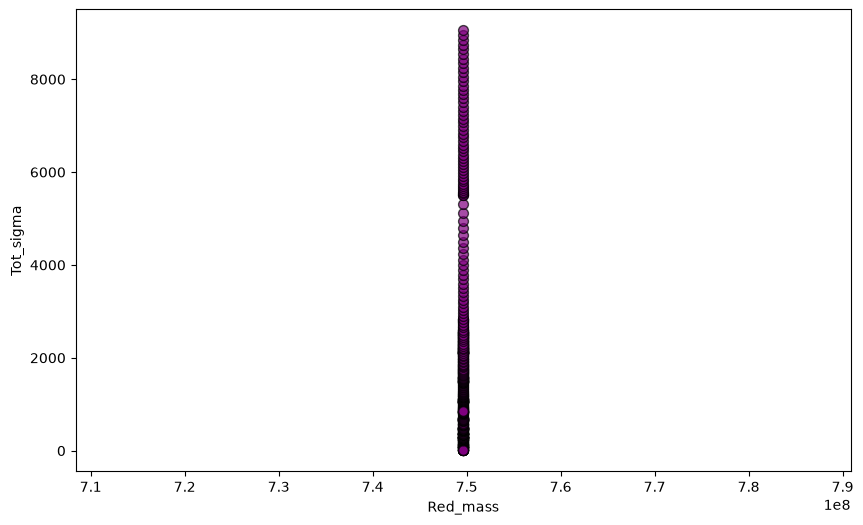

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# wczytywanie
dane = pd.read_csv("wyciagniete_dane.txt", sep=';')

dane.columns = dane.columns.str.replace(';', '').str.strip()

print("Dostępne kolumny:", dane.columns) 

x = dane['Red_mass']
y = dane['Tot_sigma']

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='purple', alpha=0.7, edgecolors='black', s=50)
plt.xlabel('Red_mass')
plt.ylabel('Tot_sigma')
plt.show()

Zredukowana masa będzię stała bo to te same cząstki

Dostępne kolumny: Index(['File_name', 'Red_mass', 'CM_energy', 'Rel_speed', 'Tot_sigma',
       'Tot_sigma_units'],
      dtype='str')


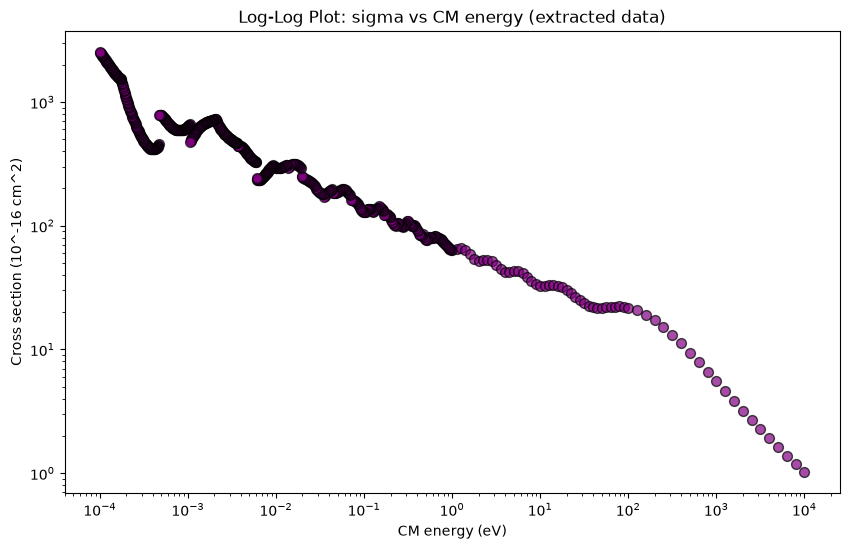

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

dane = pd.read_csv("wyciagniete_dane.txt", sep=';')

dane.columns = dane.columns.str.replace(';', '').str.strip()

wsp_sigma = 0.28002852056 
dane['Tot_sigma_units'] = dane['Tot_sigma'] * wsp_sigma

print("Dostępne kolumny:", dane.columns) 

x = dane['CM_energy']
y = dane['Tot_sigma_units']

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='purple', alpha=0.7, edgecolors='black', s=50)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('CM energy (eV)')
plt.ylabel('Cross section (10^-16 cm^2)')
plt.title('Log-Log Plot: sigma vs CM energy (extracted data)')
plt.show()

co tu sie dzieje i z czego to wynika 
relatywistyka?
-> relatywistyka, chodzi o konkretne wzbudzane przejścia energetyczne, szczególnie widoczne dla małych energii

Dostępne kolumny: Index(['File_name', 'Red_mass', 'CM_energy', 'Rel_speed', 'Tot_sigma',
       'Rel_speed_units', 'Tot_sigma_units'],
      dtype='str')


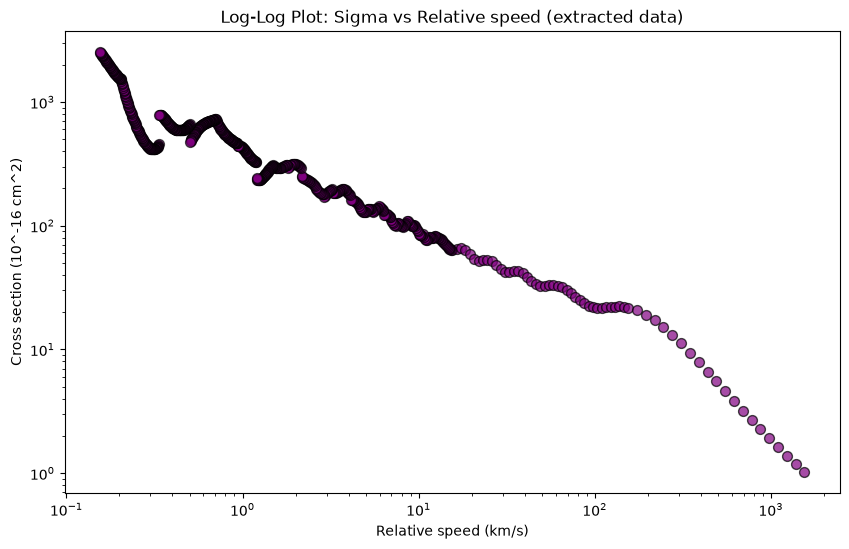

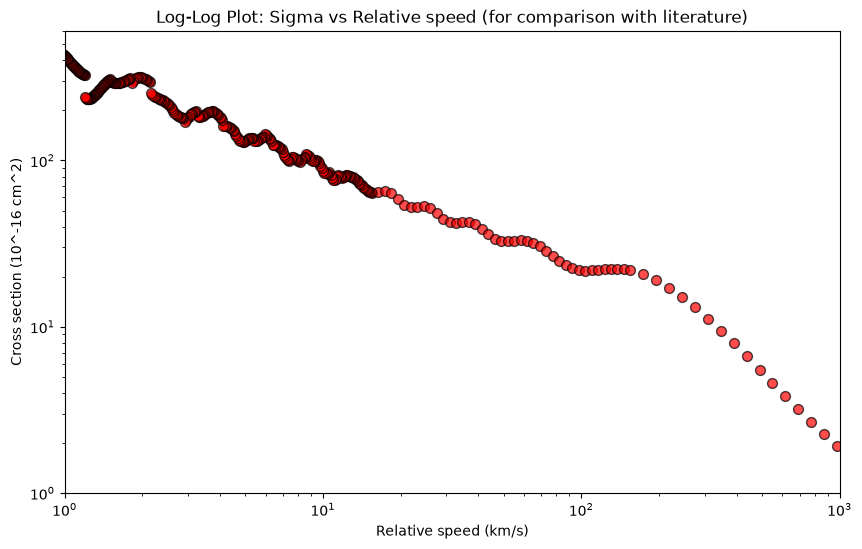

In [16]:
import pandas as pd
import matplotlib.pyplot as plt


dane = pd.read_csv("wyciagniete_dane.txt", sep=';')
dane.columns = dane.columns.str.replace(';', '').str.strip()

wsp_velocity = 10 ** -5
wsp_sigma = 0.28002852056 

dane['Rel_speed_units'] = dane['Rel_speed'] * wsp_velocity
dane['Tot_sigma_units'] = dane['Tot_sigma'] * wsp_sigma

print("Dostępne kolumny:", dane.columns) 

x = dane['Rel_speed_units']
y = dane['Tot_sigma_units']

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='purple', alpha=0.7, edgecolors='black', s=50)
plt.xscale('log') 
plt.yscale('log')
plt.title('Log-Log Plot: Sigma vs Relative speed (extracted data)')
plt.xlabel('Relative speed (km/s)')
plt.ylabel('Cross section (10^-16 cm^2)')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='red', alpha=0.7, edgecolors='black', s=50)
plt.xscale('log') 
plt.yscale('log')
plt.axis([1, 1000, 1, 600])
plt.title('Log-Log Plot: Sigma vs Relative speed (for comparison with literature)')
plt.xlabel('Relative speed (km/s)')
plt.ylabel('Cross section (10^-16 cm^2)')
plt.show()